In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

In [12]:
import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
samples, cns = cdu.main_load("raw")

WARN: Found unknown sex values: [nan]. Replacing with 'NA'. Use ['xx', 'xy'].


In [16]:
top = samples["type"].value_counts()[:6]
top_6 = samples[samples["type"].isin(top.index)]
print(top_6.shape)
subset = top_6.query("age > 0")
subset.shape

(5257, 8)


(4841, 8)

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Prepare data: drop rows with missing age or type
rf_data = subset.dropna(subset=["age", "type"])
X_rf = rf_data[["age"]]
y_rf = rf_data["type"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

# Train Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Predict and report
y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        BRCA       0.38      0.61      0.47       221
        KIRC       0.00      0.00      0.00        93
        LUAD       0.36      0.57      0.44       237
        LUSC       0.34      0.34      0.34       185
          OV       0.00      0.00      0.00       121
        PRAD       0.23      0.12      0.15       112

    accuracy                           0.36       969
   macro avg       0.22      0.27      0.23       969
weighted avg       0.27      0.36      0.30       969



c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


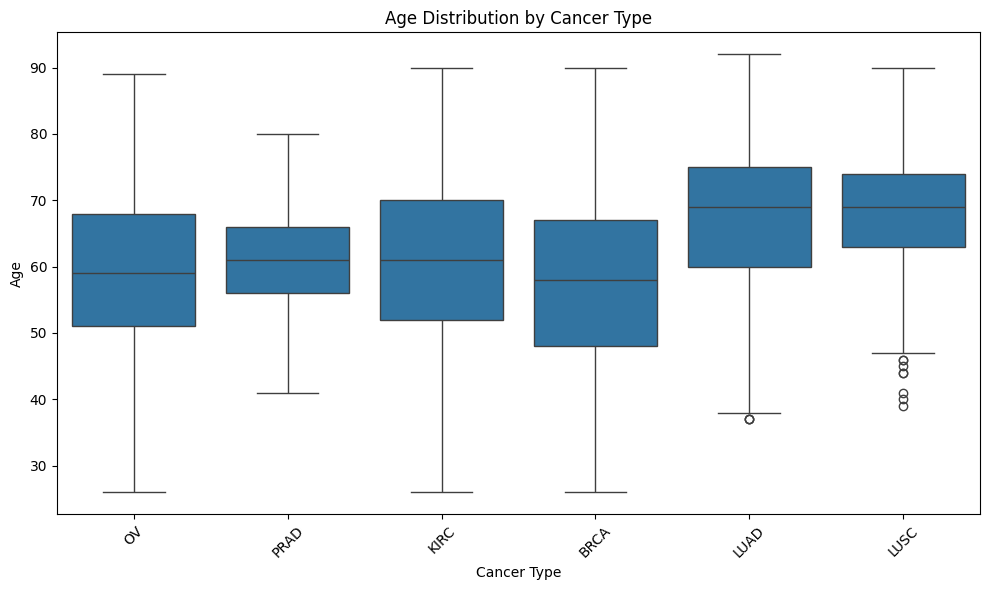

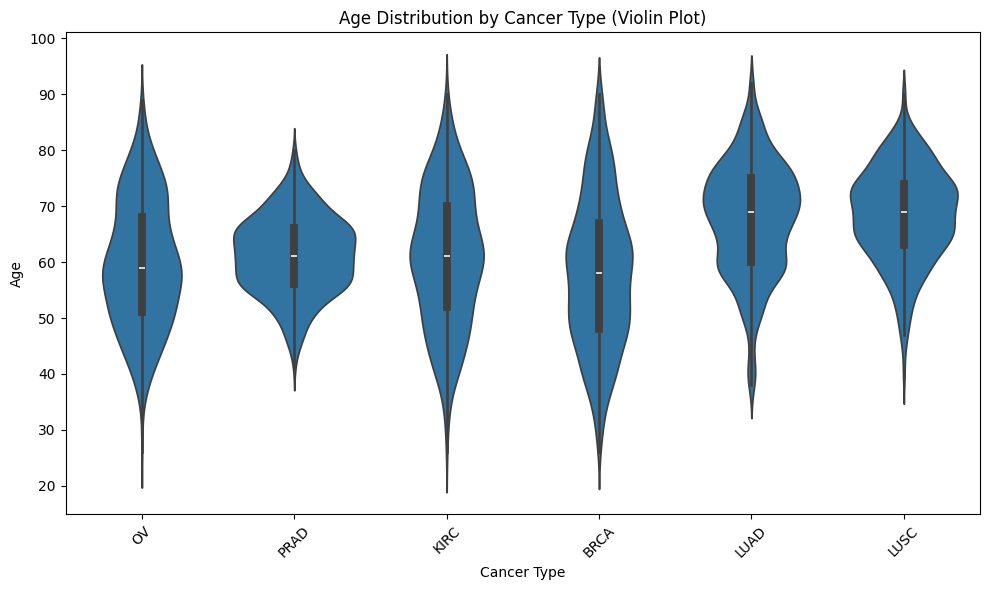

In [13]:
# Create a box plot of age distribution by cancer type
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='age', data=subset)
plt.title('Age Distribution by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also create a violin plot for better distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(x='type', y='age', data=subset)
plt.title('Age Distribution by Cancer Type (Violin Plot)')
plt.xlabel('Cancer Type')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.3560
